# Trabajo Semanal 2
### Joaquin Ezequiel Alvarez Olmedo

Teniendo la siguiente red circuital Ackerberg-Mossberg se pide hallar la transferencia y sus parametros de diseño:

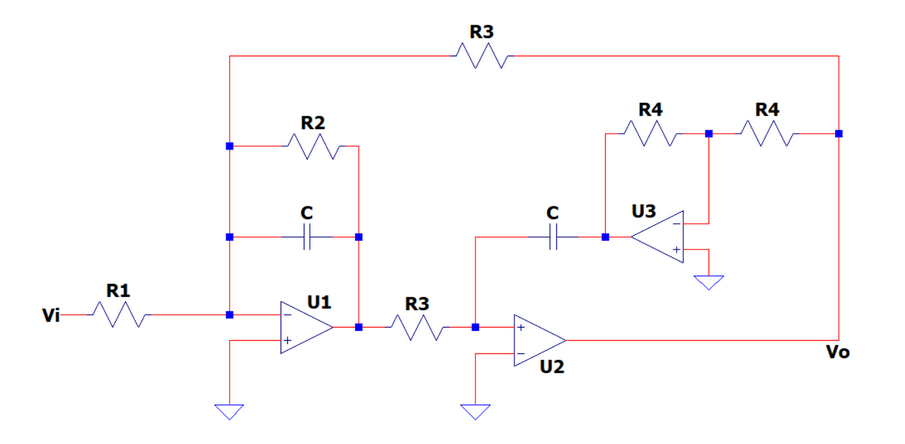

Comenzamos planteando las ecuaciones de nodos:

1) $ V_x(\frac{1}{R_1} + \frac{1}{R_2} + \frac{1}{R_3} + SC_1) - V_i(\frac{1}{R_1}) - V_a(\frac{1}{R_2} + SC_1) - V_o(\frac{1}{R_3}) = 0 $
   
2) $ V_y(\frac{1}{R_3} + SC_2) - V_a(\frac{1}{R_3}) - V_b(SC_2) = 0 $
   
3) $ V_z(2\frac{1}{R_4}) - V_b(\frac{1}{R_4}) - V_o(\frac{1}{R_4}) = 0 $

Podemos considerar Vx = 0 y Vy = 0 debido a las caracteristicas del OP AMP. A su vez conociendo las caracteristicas de la configuración inversora predecimos que Vb = -Vo (En el nodo de salida de U3). Desarrollamos la ecuación 2:

$ -V_a(\frac{1}{R_3}) - V_b(SC_2) = 0 $

$ V_a = V_o(SC_2R_3) $

Reemplazamos los valores en la ecuación 1. Luego de hacer el álgebra llegamos a la siguiente transferencia:

$ T(S) = \frac{-\frac{R_3}{R_1}\frac{1}{C_1C_2R_3^{2}}}{S^{2} + S\frac{1}{C_1R_2} + \frac{1}{C_1C_2R_3^{2}}} $

Para simplificar el diseño haremos que C1 = C2. Dicho esto obtenemos los parametros w0, Q y K: 

$ w_0 = \sqrt{\frac{1}{C^{2}R_3^{2}}} $

$ Q = \frac{R_2}{R_3} $

$ K = -\frac{R_3}{R_1} $

Tiene sentido que el K coincida con la ganancia de la seccion no inversora. Las otras 2 secciones integradoras definieron el orden de la transferencia.

<br><br><br><br>

Existe otra virtud del Ackerberg-Mossberg que nos permite confeccionar un filtro pasabanda sin modificar ningun componente del circuito. Según el libro de Schaumann podemos lograr esto si salimos por el nodo Va (salida de U1)... ¿Será posible? No queda otra que analizarlo.

Buscamos $ T(S) = \frac{V_a}{V_i} $

De la ecuacion 2: $ V_o = \frac{V_a}{SC_2R_3} $

Reemplazando en la ecuacion 1 y luego de un poco de algebra se obtiene:

$ T(S) = \frac{-R_2}{R_1} * \frac{S * \frac{1}{C_1R_2}}{S^2 + S * \frac{1}{C_1R_2} + \frac{1}{C_1C_2R_2R_3}} $

Hemos demostrado que utilizando exactamente el mismo circuito, saliendo por otro nodo, obtuvimos una transferencia pasabanda.

<br><br><br><br>

Para esta tarea tambien se pide implementar un filtro pasabajos Chebyshev usando la siguiente plantilla:

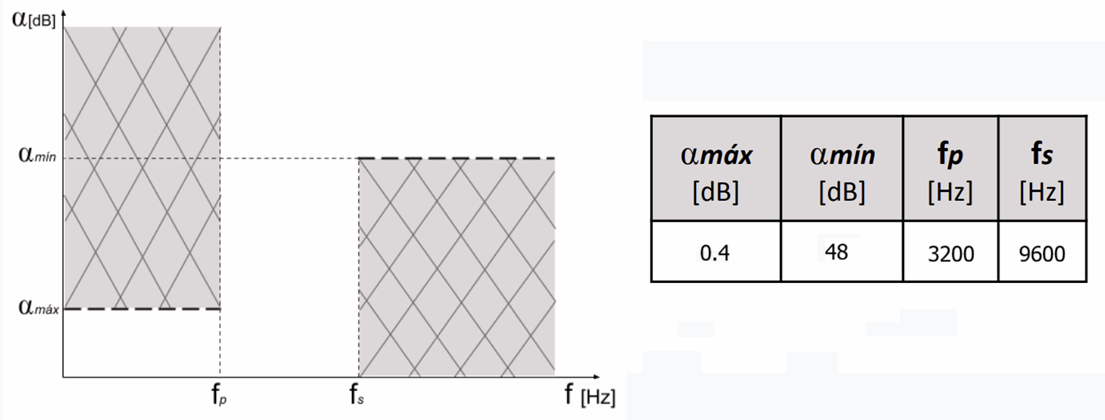

Lo primero que debemos calcular es el orden del filtro y su $ \xi^2 $:

$ \xi^2 = 10^{\frac{\alpha max}{10}} - 1 = 10^{\frac{0.4dB}{10}} - 1 \approx 0,1 $

Con este dato estamos seguros que debemos aproximar por Chebyshev ($ \xi^2 \neq 1 $). 

$ \alpha min = 10\log{(1 + \xi^2\cosh^{2}({n\cosh^{-1}{(\omega_s)}})} = 10\log{(1 + 0.1\cosh^{2}(1.317n))} $ Donde $ \omega_s = 3 $, normalizada respecto de $ w_p $

$ n = 4,16 $, redondeamos a $ n = 5 $ ya que el filtro de orden 4 no sera capaz de cumplir con la atenuacion pedida en la plantilla.

Con estos datos, armamos $ |T(jw)|^2 $:

$ |T(jw)|^2 = \frac{1}{1 + 0.1C_5^2(\omega)} $

Desarrollamos C5:

$ C_n = 2w*C(n-1) - C(n-2) $

$ C_0 = 1 $

$ C_1 = w $

$ C_2 = 2w^2 - 1 $

$ C_3 = 4w^3 - 3w $

$ C_4 = 8w^4 - 8w^2 + 1 $

$ C_5 = 16w^5 - 20^3 + 5w $

$ |T(jw)|^2 = \frac{1}{1 + (16w^5 - 20^3 + 5w)^2} $

Para obtener T(S) resuelve por parte de función. A partir de este punto el álgebra tiende a ponerse tediosa. Para evitar errores algebraicos, simulamos. Utilizamos codigo tomado de la libreria pytc2 que nos permite obtener las transferencias de filtros de maxima planicidad el tipo de aproximacion elegida. El script es capaz de analizar distintas transferencias de distinto orden al mismo tiempo, se debe indicar que orden/es se quieren analizar. Tambien se debe indicar atenueciones maxima y minima

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi

fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

In [ ]:
from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS
from pytc2.general import print_subtitle

#%% Funcion que arma las transferencias de filtros de maxima planicidad

def sim_aprox(aproxs, orders2analyze, ripple, attenuation):

    all_sys = []
    filter_names = []

    for (this_aprox, this_order, this_ripple, this_att) in zip(aproxs, orders2analyze, ripple, attenuation):

        if this_aprox == 'Butterworth':

            z,p,k = sig.buttap(this_order)

            eps = np.sqrt( 10**(this_ripple/10) - 1 )
            num, den = sig.zpk2tf(z,p,k)
            num, den = sig.lp2lp(num, den, eps**(-1/this_order))

            z,p,k = sig.tf2zpk(num, den)

        elif this_aprox == 'Chebyshev1':

            z,p,k = sig.cheb1ap(this_order, this_ripple)

        elif this_aprox == 'Chebyshev2':

            z,p,k = sig.cheb2ap(this_order, this_att)

        elif this_aprox == 'Bessel':

            z,p,k = sig.besselap(this_order, norm='delay')

        elif this_aprox == 'Cauer':

            z,p,k = sig.ellipap(this_order, this_ripple, this_att)


        num, den = sig.zpk2tf(z,p,k)

        
        all_sys.append(sig.TransferFunction(num,den))

        this_label = this_aprox + '_ord_' + str(this_order) + '_rip_' + str(this_ripple)+ '_att_' + str(this_att)
        
        print_subtitle(this_label)
        # factorizamos en SOS's
        this_sos = tf2sos_analog(num, den)
        
        pretty_print_SOS(this_sos, mode='omegayq')
        
        filter_names.append(this_label)
        
    # el caracter "_" descarta la salida de la función
    _ = analyze_sys( all_sys, filter_names )

    return( all_sys, filter_names )

#%% En esta seccion elegimos el tipo de filtro que buscamos simular

#aprox_name = 'Butterworth'
aprox_name = 'Chebyshev1'
#aprox_name = 'Chebyshev2'
#aprox_name = 'Bessel'
#aprox_name = 'Cauer'

# parametrizamos el orden para cada aproximación
orders2analyze = [5]

# Mismo requerimiento de ripple y atenuación
aproxs = [aprox_name] * len(orders2analyze)
ripple = [0.4] * len(orders2analyze) # Alfa maximo en dB
attenuation = [48] * len(orders2analyze) # Alfa minimo en dB

( all_sys, filter_names ) = sim_aprox(aproxs, orders2analyze, ripple, attenuation)

Podemos implementar el Ackerberg-Mossberg para armar las 2 secciones de 2° orden. Faltaria una seccion de 1° orden la cual se pide que sea un pasabajos RC.

$ T_1(S) = \frac{w_0}{S + w_0} = \frac{\frac{1}{SC}}{\frac{1}{SC} + R} = \frac{1}{SCR + 1} = \frac{\frac{1}{RC}}{S + \frac{1}{RC}}$

Donde $ w_0 = \frac{1}{RC} $

Normalizamos en frecuencia y luego impedancia respecto de R1: 

$ \frac{1}{RC} = 1 $

$ R = \frac{1}{C} $ y si R = 1: C = 1

A continuación un esquema de la seccion RC de 1° orden normalizada:

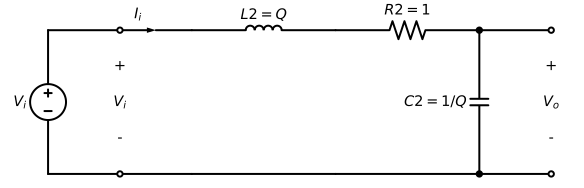

In [ ]:
d = Drawing(unit=4)
d = dibujar_elemento_derivacion(d, "V",  with_nodes=False, sym_label="V_i")
d = dibujar_espacio_derivacion(d)
d = dibujar_puerto_entrada(d, voltage_lbl=('+', to_latex('V_i'), '-'), current_lbl=to_latex('I_i'))
d = dibujar_elemento_serie(d, "R", sym_label="R = 1")
d = dibujar_elemento_derivacion(d, "C", sym_label="C = 1")
d = dibujar_puerto_salida(d, voltage_lbl=('+', to_latex('V_o'), '-'))
display(d)